<a href="https://colab.research.google.com/github/debashisdotchatterjee/RC2026IOT-Robotics-Assignment-Solution-code_Debashis-Chatterjee1/blob/main/Assignment_Verification_RC_IIT_MANDI_2026_(1%2C_DC)_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IIT Mandi Refresher Course 2026 — Assignment Numerical Verification

**Use:** Need to Run all cells in Google Colab. The notebook displays all tables and figures inline, exports publication-quality PNG/CSV/JSON files, then downloads one ZIP.

**Scope:** Q4, Q7, Q14, Q15 and a **synthetic** illustration for Q17. All 17 complete analytical solutions and the verbatim questions are in `solution.tex`.

**Important:** Q14(b) is closed-loop unstable; naive steady-state error constants cannot be interpreted as actual steady-state errors.


In [1]:
%pip -q install numpy scipy sympy pandas matplotlib


IIT MANDI 2026 — Numerical Verification for Assignment Questions 4, 7, 14, 15, 17
This notebook supplies independent verification, not substituted hypothetical assignment data.

Q4: eigenvalue verification


,closed_loop_eigenvalue
0,-4.0
1,-2.0


Table saved: /content/iit_mandi_assignment_output/tables/q04_pole_placement.csv
Figure saved: /content/iit_mandi_assignment_output/figures/q07_nonlinear_phase.png


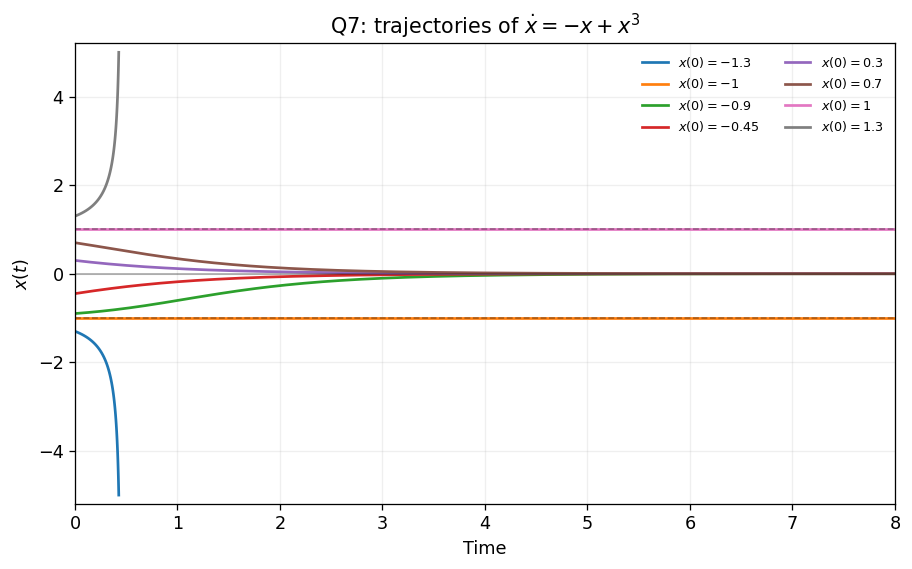


Q7: equilibrium and derivative test


,equilibrium,f_prime,classification
0,-1.0,2.0,unstable
1,0.0,-1.0,locally asymptotically stable
2,1.0,2.0,unstable


Table saved: /content/iit_mandi_assignment_output/tables/q07_equilibria.csv

Q14(a): exact Routh array


,power,col_1,col_2
0,3,1,1375
1,2,70,6000
2,1,9025/7,0
3,0,6000,0


Table saved: /content/iit_mandi_assignment_output/tables/Q14_a_routh.csv

Q14(b): exact Routh array


,power,col_1,col_2,col_3
0,5,1,3875,500
1,4,110,43760,6000
2,3,38249/11,4900/11,0
3,2,1673237240/38249,6000,0
4,1,-1316030750/41830931,0,0
5,0,6000,0,0


Table saved: /content/iit_mandi_assignment_output/tables/Q14_b_routh.csv
Figure saved: /content/iit_mandi_assignment_output/figures/q14_closed_loop_poles.png


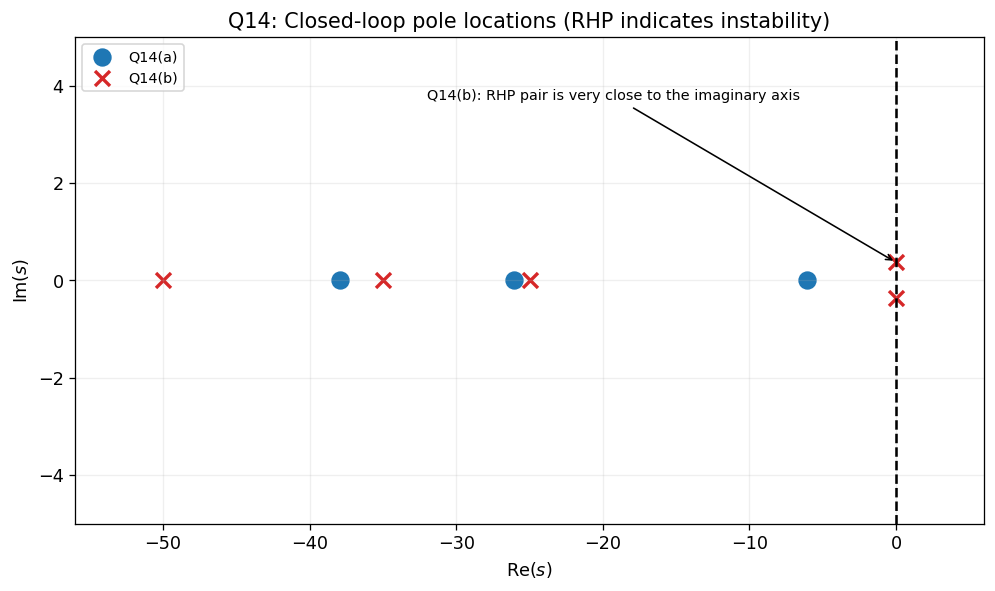


Q14: pole list; numerical confirmation of exact Routh criterion


,system,index,real,imag,location
0,Q14(a),1,-37.890103,0.000000,LHP
1,Q14(a),2,-26.025338,0.000000,LHP
2,Q14(a),3,-6.084559,0.000000,LHP
3,Q14(b),1,-50.006397,0.000000,LHP
4,Q14(b),2,-34.995921,0.000000,LHP
5,Q14(b),3,-24.998400,0.000000,LHP
6,Q14(b),4,0.000359,0.370338,RHP
7,Q14(b),5,0.000359,-0.370338,RHP


Table saved: /content/iit_mandi_assignment_output/tables/q14_poles.csv
Q14(a) actual reference errors: step=0, ramp=35/16, parabolic=no finite limit
Q14(b) UNSTABLE: all textbook Type-2 final-value answers are INAPPLICABLE.
Figure saved: /content/iit_mandi_assignment_output/figures/q15_root_locus.png


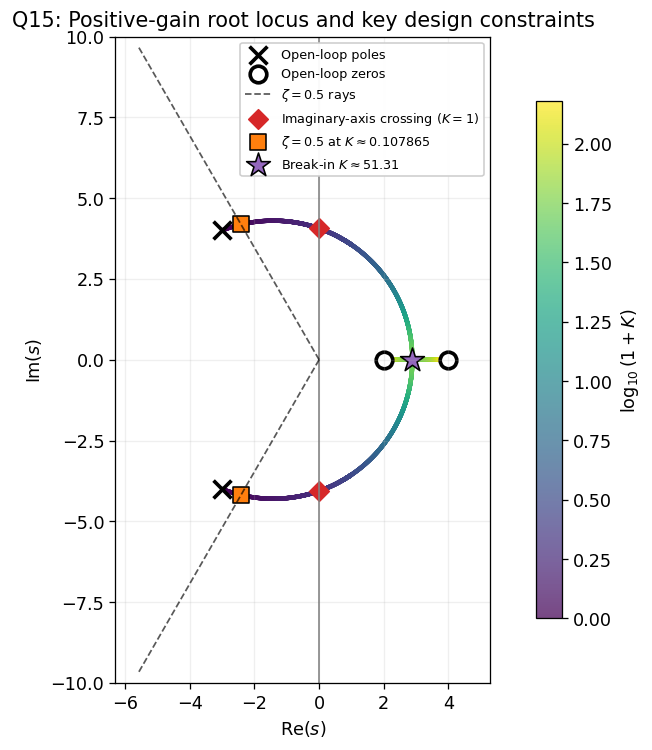

Figure saved: /content/iit_mandi_assignment_output/figures/q15_damping_vs_gain.png


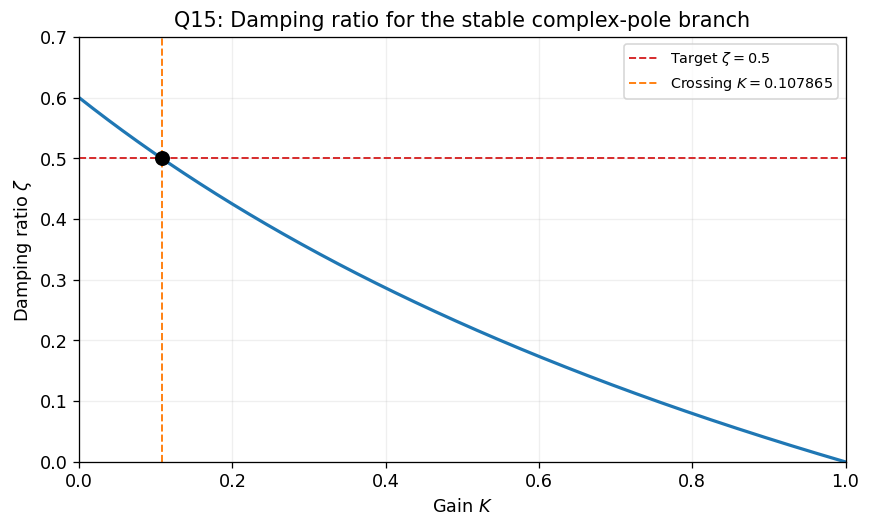


Q15: numerically evaluated critical points


,event,K,real,imag
0,Imaginary axis (+),1.000000,0.000000,4.062019
1,Imaginary axis (-),1.000000,0.000000,-4.062019
2,Break-in,51.311819,2.885303,0.000000
3,Zeta 0.5 (+),0.107865,-2.415825,4.184331
4,Zeta 0.5 (-),0.107865,-2.415825,-4.184331


Table saved: /content/iit_mandi_assignment_output/tables/q15_critical_points.csv

Q17 SYNTHETIC data example — this is NOT a dataset from the assignment.
Figure saved: /content/iit_mandi_assignment_output/figures/q17_dmd_verification.png


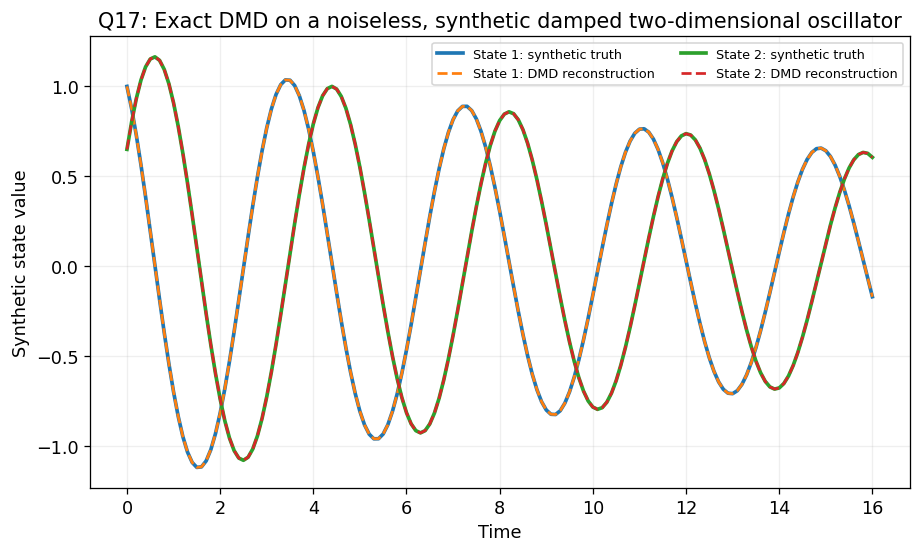


Q17: DMD modes from SYNTHETIC example


,mode,eigen_real,eigen_imag,discrete_magnitude,frequency_rad_per_sec,continuous_growth_rate
0,1,0.982481,-0.163597,0.996008,-1.65,-0.04
1,2,0.982481,0.163597,0.996008,1.65,-0.04


Table saved: /content/iit_mandi_assignment_output/tables/q17_dmd_eigenvalues.csv

Completed all notebook tasks. ZIP generated at: /content/iit_mandi_assignment_verification.zip
Total output files: 17
Q14(a): stable; Q14(b): unstable (two RHP poles)
Q17 dataset is explicitly synthetic.
Starting browser download of the complete figures/tables/JSON ZIP...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
"""IIT Mandi 2026 refresher-course assignment: reproducible supplementary numerics.

Run in Google Colab (or locally). It prints results inline, displays figures,
exports tables/figures/README, and makes a downloadable ZIP in Colab.

No assignment measurement data were provided: Q17 uses explicitly SYNTHETIC data.
Theoretical answers are in solution.tex. This file is NOT a substitute for them.
"""
from pathlib import Path
import json
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.integrate import solve_ivp
from scipy.linalg import eigvals
import sympy as sp
from IPython.display import display

try:
    from google.colab import files as colab_files
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

OUT = Path('/content/iit_mandi_assignment_output') if ON_COLAB else (Path.cwd() / 'iit_mandi_assignment_output')
FIG = OUT / 'figures'
TAB = OUT / 'tables'
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 115,
    'savefig.dpi': 220,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'grid.alpha': 0.20,
})
SUMMARY = {}


def save_show(fig, filename):
    path = FIG / filename
    fig.savefig(path, bbox_inches='tight', dpi=220)
    print('Figure saved:', path)
    display(fig)
    plt.close(fig)


def display_save_table(frame, filename, caption):
    print('\n' + caption)
    display(frame)
    path = TAB / filename
    frame.to_csv(path, index=False)
    print('Table saved:', path)


print('IIT MANDI 2026 — Numerical Verification for Assignment Questions 4, 7, 14, 15, 17')
print('This notebook supplies independent verification, not substituted hypothetical assignment data.')

# -----------------------------------------------------------------------------
# Q4: feedback pole placement independent check
# -----------------------------------------------------------------------------
A = np.array([[0., 1.], [0., -2.]])
B = np.array([[0.], [2.]])
K = np.array([[4., 2.]])
Acl = A - B @ K
q4_poles = np.sort(np.linalg.eigvals(Acl).real)
np.testing.assert_allclose(q4_poles, [-4., -2.], rtol=0, atol=1e-12)
q4_table = pd.DataFrame({'closed_loop_eigenvalue': q4_poles})
display_save_table(q4_table, 'q04_pole_placement.csv', 'Q4: eigenvalue verification')
SUMMARY['Q4'] = {'K': K.ravel().tolist(), 'closed_loop_eigenvalues': q4_poles.tolist()}

# -----------------------------------------------------------------------------
# Q7: nonlinear phase trajectories, and sign of derivative at all equilibria
# -----------------------------------------------------------------------------
def f7(t, x):
    return [-x[0] + x[0]**3]


def stop_at_large_magnitude(t, x):
    return 5.0 - abs(x[0])

stop_at_large_magnitude.terminal = True
stop_at_large_magnitude.direction = -1
fig, ax = plt.subplots(figsize=(9.2, 5.2))
starts = [-1.3, -1.0, -0.9, -0.45, 0.3, 0.7, 1.0, 1.3]
q7_records = []
for x0 in starts:
    sol = solve_ivp(f7, (0, 8), [float(x0)], events=stop_at_large_magnitude,
                    rtol=1e-9, atol=1e-11, max_step=0.025, dense_output=False)
    ax.plot(sol.t, sol.y[0], lw=1.7, label=f'$x(0)={x0:g}$')
    q7_records.extend({'initial_x': x0, 'time': t, 'x': x} for t, x in zip(sol.t, sol.y[0]))
for val, style in [(-1.0, '--'), (0.0, '-'), (1.0, '--')]:
    ax.axhline(val, ls=style, color='black', alpha=0.34, lw=1.0)
ax.set(title=r'Q7: trajectories of $\dot{x}= -x+x^3$', xlabel='Time', ylabel='$x(t)$',
       ylim=(-5.2, 5.2), xlim=(0, 8))
ax.grid(True)
ax.legend(ncol=2, loc='upper right', frameon=False, fontsize=8)
save_show(fig, 'q07_nonlinear_phase.png')
display_save_table(pd.DataFrame({'equilibrium': [-1.0, 0.0, 1.0],
                                'f_prime': [2.0, -1.0, 2.0],
                                'classification': ['unstable', 'locally asymptotically stable', 'unstable']}),
                   'q07_equilibria.csv', 'Q7: equilibrium and derivative test')
pd.DataFrame(q7_records).to_csv(TAB / 'q07_trajectories.csv', index=False)
SUMMARY['Q7'] = {'equilibria': [-1, 0, 1], 'f_prime': [2, -1, 2]}

# -----------------------------------------------------------------------------
# Q14: exact characteristic polys, Routh arrays, numeric pole confirmations
# -----------------------------------------------------------------------------
s = sp.symbols('s', real=True)
N = 10 * (s + 20) * (s + 30)
D1 = s * (s + 25) * (s + 35)
D2 = s**2 * (s + 25) * (s + 35) * (s + 50)
P1 = sp.expand(D1 + N)
P2 = sp.expand(D2 + N)
assert sp.Poly(P1, s).all_coeffs() == [1, 70, 1375, 6000]
assert sp.Poly(P2, s).all_coeffs() == [1, 110, 3875, 43760, 500, 6000]


def exact_routh(poly):
    """Basic exact Routh array; no zero pivots occur for these two examples."""
    coeff = list(sp.Poly(poly, s).all_coeffs())
    number_of_rows = len(coeff)
    number_of_columns = (number_of_rows + 1) // 2
    rr = [[sp.Integer(0) for _ in range(number_of_columns)] for _ in range(number_of_rows)]
    rr[0][:len(coeff[0::2])] = coeff[0::2]
    rr[1][:len(coeff[1::2])] = coeff[1::2]
    for i in range(2, number_of_rows):
        pivot = rr[i - 1][0]
        if pivot == 0:
            raise ArithmeticError('This example unexpectedly requires epsilon Routh handling.')
        for j in range(number_of_columns - 1):
            rr[i][j] = sp.factor((pivot * rr[i-2][j+1] - rr[i-2][0] * rr[i-1][j+1]) / pivot)
    return rr


pole_records = []
fig, ax = plt.subplots(figsize=(10.2, 5.5))
for label, poly, marker, color in [('Q14(a)', P1, 'o', 'tab:blue'),
                                  ('Q14(b)', P2, 'x', 'tab:red')]:
    coefficients = np.asarray([float(z) for z in sp.Poly(poly, s).all_coeffs()])
    roots = np.roots(coefficients)
    rr = exact_routh(poly)
    signs = [sp.sign(row[0]) for row in rr]
    sign_changes = sum(signs[i] != signs[i-1] for i in range(1, len(signs)))
    n_right = int(np.sum(roots.real > 1e-8))
    assert sign_changes == n_right, f'Routh/numerical check failed: {label}'
    routh_frame = pd.DataFrame([{'power': len(rr)-1-i, **{f'col_{j+1}': str(value)
                              for j, value in enumerate(row)}} for i, row in enumerate(rr)])
    display_save_table(routh_frame, f'{label.replace("(", "_").replace(")", "")}_routh.csv',
                       label + ': exact Routh array')
    for index, root in enumerate(roots):
        pole_records.append({'system': label, 'index': index+1,
                             'real': float(root.real), 'imag': float(root.imag),
                             'location': 'RHP' if root.real > 1e-8 else ('LHP' if root.real < -1e-8 else 'imaginary axis')})
    ax.scatter(roots.real, roots.imag, s=88, c=color, marker=marker, lw=2.1, label=label)
    SUMMARY[label] = {'characteristic_coefficients': coefficients.tolist(),
                      'RHP_pole_count': n_right, 'routh_sign_changes': sign_changes,
                      'poles': [{'real': float(v.real), 'imag': float(v.imag)} for v in roots]}
ax.axvline(0, lw=1.6, color='black', ls='--')
ax.set(xlabel=r'Re$(s)$', ylabel=r'Im$(s)$',
       title='Q14: Closed-loop pole locations (RHP indicates instability)', xlim=(-56, 6), ylim=(-5, 5))
ax.grid(True)
ax.legend(loc='upper left')
ax.annotate('Q14(b): RHP pair is very close to the imaginary axis',
            xy=(0.0003, 0.37), xytext=(-32, 3.7),
            arrowprops=dict(arrowstyle='->', lw=1), fontsize=9)
save_show(fig, 'q14_closed_loop_poles.png')
display_save_table(pd.DataFrame(pole_records), 'q14_poles.csv', 'Q14: pole list; numerical confirmation of exact Routh criterion')
Ka_formal = sp.factor((s**2 * N / D2).limit(s, 0))
Kv1 = sp.factor((s * N / D1).limit(s, 0))
assert Kv1 == sp.Rational(48, 7)
assert Ka_formal == sp.Rational(24, 175)
assert SUMMARY['Q14(a)']['RHP_pole_count'] == 0
assert SUMMARY['Q14(b)']['RHP_pole_count'] == 2
print('Q14(a) actual reference errors: step=0, ramp=35/16, parabolic=no finite limit')
print('Q14(b) UNSTABLE: all textbook Type-2 final-value answers are INAPPLICABLE.')

# -----------------------------------------------------------------------------
# Q15: root-locus branches + all analytically identified critical points
# -----------------------------------------------------------------------------
K_damping = float((105 - sp.sqrt(9793)) / 56)
a_damping = 3*(1-K_damping)/(1+K_damping)
s_damping = complex(-a_damping, np.sqrt(3)*a_damping)
K_break = float((51 + sp.sqrt(2665)) / 2)
s_break = float((-17 + sp.sqrt(2665)) / 12)
omega_axis = np.sqrt(33/2)

K_values = np.concatenate(([0.0], np.linspace(0.0002, 2.0, 1400),
                           np.geomspace(2.001, 150.0, 1400)))
branch_records = []
branches = []
for gain in K_values:
    roots = np.roots([1+gain, 6*(1-gain), 25+8*gain])
    # Sort only for a useful top/bottom plotting convention; branches merge on real axis.
    roots = sorted(roots, key=lambda z: (z.imag, z.real))
    branches.append(roots)
    branch_records.extend({'K': gain, 'root_id': j, 'real': float(root.real), 'imag': float(root.imag)}
                          for j, root in enumerate(roots))
branches = np.asarray(branches)
fig, ax = plt.subplots(figsize=(10.3, 7.3))
for j in [0, 1]:
    dots = ax.scatter(branches[:, j].real, branches[:, j].imag, c=np.log10(1+K_values),
                      cmap='viridis', s=3.1, alpha=0.72, rasterized=True)
ax.scatter([-3, -3], [-4, 4], marker='x', s=125, color='black', lw=2.3, label='Open-loop poles')
ax.scatter([2, 4], [0, 0], facecolors='white', edgecolors='black', s=108,
           lw=2.3, label='Open-loop zeros')
ax.axvline(0, color='gray', lw=1.0)
ray_a = np.linspace(0, 5.6, 100)
ax.plot(-ray_a, np.sqrt(3)*ray_a, 'k--', lw=1.1, alpha=0.65, label=r'$\zeta=0.5$ rays')
ax.plot(-ray_a, -np.sqrt(3)*ray_a, 'k--', lw=1.1, alpha=0.65)
ax.scatter([0, 0], [omega_axis, -omega_axis], s=75, marker='D', color='tab:red',
           label=r'Imaginary-axis crossing ($K=1$)')
ax.scatter([s_damping.real]*2, [s_damping.imag, -s_damping.imag],
           marker='s', s=92, facecolors='tab:orange', edgecolors='black',
           label=r'$\zeta=0.5$ at $K\approx 0.107865$')
ax.scatter([s_break], [0], marker='*', s=245, facecolors='tab:purple',
           edgecolors='black', label=r'Break-in $K\approx51.31$')
ax.set(xlim=(-6.3, 5.3), ylim=(-10, 10), xlabel=r'Re$(s)$', ylabel=r'Im$(s)$',
       title='Q15: Positive-gain root locus and key design constraints')
ax.grid(True)
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='upper right', fontsize=8, framealpha=0.96)
cbar = fig.colorbar(dots, ax=ax, shrink=0.8)
cbar.set_label(r'$\log_{10}(1+K)$')
save_show(fig, 'q15_root_locus.png')
pd.DataFrame(branch_records).to_csv(TAB / 'q15_root_locus_points.csv', index=False)

# Only the stable conjugate-complex branch, 0 <= K < 1.
kg = np.linspace(0.0, 0.999, 900)
zetas = []
for gain in kg:
    roots = np.roots([1+gain, 6*(1-gain), 25+8*gain])
    root = max(roots, key=lambda z: z.imag)
    zetas.append(-root.real / abs(root))
fig, ax = plt.subplots(figsize=(8.6, 4.8))
ax.plot(kg, zetas, lw=2.0, color='tab:blue')
ax.axhline(0.5, color='tab:red', ls='--', lw=1.2, label=r'Target $\zeta=0.5$')
ax.axvline(K_damping, color='tab:orange', ls='--', lw=1.2,
           label=rf'Crossing $K={K_damping:.6f}$')
ax.scatter([K_damping], [0.5], zorder=10, marker='o', s=70, color='black')
ax.set(xlabel='Gain $K$', ylabel=r'Damping ratio $\zeta$',
       title='Q15: Damping ratio for the stable complex-pole branch', xlim=(0, 1), ylim=(0, .7))
ax.grid(True)
ax.legend()
save_show(fig, 'q15_damping_vs_gain.png')
critical = pd.DataFrame([
    {'event': 'Imaginary axis (+)', 'K': 1.0, 'real': 0, 'imag': omega_axis},
    {'event': 'Imaginary axis (-)', 'K': 1.0, 'real': 0, 'imag': -omega_axis},
    {'event': 'Break-in', 'K': K_break, 'real': s_break, 'imag': 0},
    {'event': 'Zeta 0.5 (+)', 'K': K_damping, 'real': s_damping.real, 'imag': s_damping.imag},
    {'event': 'Zeta 0.5 (-)', 'K': K_damping, 'real': s_damping.real, 'imag': -s_damping.imag},
])
display_save_table(critical, 'q15_critical_points.csv', 'Q15: numerically evaluated critical points')
assert np.isclose(28*K_damping**2 - 105*K_damping + 11, 0, atol=1e-9)
assert np.isclose(s_break**2 + 6*s_break + 25 + K_break*(s_break-2)*(s_break-4), 0, atol=1e-9)
assert 0 < K_damping < 1 < K_break
SUMMARY['Q15'] = {'imaginary_crossing_K': 1.0, 'imaginary_crossing_omega': omega_axis,
                  'break_in_K': K_break, 'break_in_s': s_break,
                  'damping_ratio_half_K': K_damping,
                  'damping_ratio_half_s': {'real': s_damping.real, 'imag': s_damping.imag},
                  'positive_gain_stable_interval': '0 <= K < 1'}

# -----------------------------------------------------------------------------
# Q17: clearly SYNTHETIC linear damped rotation, sampled without noise
# -----------------------------------------------------------------------------
print('\nQ17 SYNTHETIC data example — this is NOT a dataset from the assignment.')
dt = 0.1
alpha = -0.04
frequency = 1.65
rotation = np.array([[np.cos(frequency*dt), -np.sin(frequency*dt)],
                     [np.sin(frequency*dt), np.cos(frequency*dt)]])
A_true = np.exp(alpha*dt) * rotation
x0 = np.array([1.0, .65])
num_steps = 160
sequence = np.zeros((2, num_steps+1))
sequence[:, 0] = x0
for k in range(num_steps):
    sequence[:, k+1] = A_true @ sequence[:, k]
X, Y = sequence[:, :-1], sequence[:, 1:]
U, singular_values, Vh = np.linalg.svd(X, full_matrices=False)
r = 2
Ur = U[:, :r]
Sr = np.diag(singular_values[:r])
Vr = Vh.conj().T[:, :r]
Atilde = Ur.conj().T @ Y @ Vr @ np.linalg.inv(Sr)
eigenvalues, W = np.linalg.eig(Atilde)
Phi = Y @ Vr @ np.linalg.inv(Sr) @ W
b = np.linalg.pinv(Phi) @ x0
reconstructed = np.column_stack([Phi @ (np.power(eigenvalues, k) * b)
                                  for k in range(num_steps+1)])
reconstructed = np.real_if_close(reconstructed, tol=1000).real
max_abs_error = float(np.max(np.abs(sequence-reconstructed)))
true_eigs = np.sort_complex(np.linalg.eigvals(A_true))
dmd_eigs = np.sort_complex(eigenvalues)
np.testing.assert_allclose(np.sort(np.abs(dmd_eigs)), np.sort(np.abs(true_eigs)), atol=1e-9)
assert max_abs_error < 1e-8

fig, ax = plt.subplots(figsize=(9.2, 5.1))
times = np.arange(num_steps+1)*dt
ax.plot(times, sequence[0], label='State 1: synthetic truth', lw=2.3)
ax.plot(times, reconstructed[0], ls='--', label='State 1: DMD reconstruction', lw=1.7)
ax.plot(times, sequence[1], label='State 2: synthetic truth', lw=2.3)
ax.plot(times, reconstructed[1], ls='--', label='State 2: DMD reconstruction', lw=1.7)
ax.set(xlabel='Time', ylabel='Synthetic state value',
       title='Q17: Exact DMD on a noiseless, synthetic damped two-dimensional oscillator')
ax.grid(True)
ax.legend(loc='upper right', fontsize=8, ncol=2)
save_show(fig, 'q17_dmd_verification.png')

dmd_frame = pd.DataFrame([{'mode': j+1, 'eigen_real': float(ev.real),
                            'eigen_imag': float(ev.imag),
                            'discrete_magnitude': float(abs(ev)),
                            'frequency_rad_per_sec': float(np.angle(ev)/dt),
                            'continuous_growth_rate': float(np.log(abs(ev))/dt)}
                           for j, ev in enumerate(dmd_eigs)])
display_save_table(dmd_frame, 'q17_dmd_eigenvalues.csv', 'Q17: DMD modes from SYNTHETIC example')
pd.DataFrame({'time': times, 'state1': sequence[0], 'dmd_state1': reconstructed[0],
              'state2': sequence[1], 'dmd_state2': reconstructed[1]}).to_csv(
                  TAB / 'q17_synthetic_reconstruction.csv', index=False)
SUMMARY['Q17_synthetic'] = {'dataset_origin': 'synthetic, generated in code (NOT assignment data)',
                            'max_abs_reconstruction_error': max_abs_error,
                            'A_true': A_true.tolist(),
                            'eigenvalues': [{'real': float(z.real), 'imag': float(z.imag)} for z in dmd_eigs]}

# -----------------------------------------------------------------------------
# Export all results as one ZIP; print and display results inline first.
# -----------------------------------------------------------------------------
readme = '''IIT Mandi RC 2026 / assignment numerical verification\n\n'''
readme += 'The numerical material checks Q4, Q7, Q14 and Q15; Q17 uses SYNTHETIC data, not supplied measurements.\n'
readme += 'Q14(b) is unstable. NEVER present formal Type-2 constants as valid final values.\n\n'
(OUT / 'README.txt').write_text(readme, encoding='utf-8')
(OUT / 'verification_summary.json').write_text(json.dumps(SUMMARY, indent=2), encoding='utf-8')
zip_path = Path('/content/iit_mandi_assignment_verification.zip') if ON_COLAB else (Path.cwd() / 'iit_mandi_assignment_verification.zip')
with zipfile.ZipFile(zip_path, mode='w', compression=zipfile.ZIP_DEFLATED) as zf:
    for item in sorted(OUT.rglob('*')):
        if item.is_file():
            zf.write(item, arcname=item.relative_to(OUT))
print('\n' + '='*65)
print('Completed all notebook tasks. ZIP generated at:', zip_path)
print('Total output files:', sum(1 for p in OUT.rglob('*') if p.is_file()))
print('Q14(a): stable; Q14(b): unstable (two RHP poles)')
print('Q17 dataset is explicitly synthetic.')
print('='*65)
if ON_COLAB:
    print('Starting browser download of the complete figures/tables/JSON ZIP...')
    colab_files.download(str(zip_path))
else:
    print('Not running in Colab; find the ZIP in the current working directory.')


## After Colab finishes
Download the ZIP, inspect generated plots and tables.
